# Convert BPMN to a Directly-Follows Graph with PM4Py

**Goal:** load a BPMN 2.0 model, convert it to an accepting Petri net, simulate completed traces, discover a DFG, visualize it, and export it.

> A DFG is normally discovered from an event log, not converted losslessly from BPMN. Therefore edge counts below are **simulation frequencies**, not frequencies contained in the BPMN model. Increase `NUMBER_OF_TRACES` for more stable coverage. Loops and choices mean finite simulation cannot guarantee every possible path.

## 1. Install dependencies

Run this once if PM4Py is not installed in the notebook kernel.

In [1]:
%pip install -q "pm4py>=2.7,<3" matplotlib networkx pandas

Note: you may need to restart the kernel to use updated packages.


## 2. Configure the conversion

Change `BPMN_PATH` to convert another model. The default points to a model already present in this repository.

In [2]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import pm4py
from pm4py.algo.simulation.playout.petri_net import algorithm as petri_playout

BPMN_PATH = Path("bpmn/E_j01/2.bpmn2.xml")
NUMBER_OF_TRACES = 1_000
MAX_TRACE_LENGTH = 100
RANDOM_SEED = 42
OUTPUT_DIR = Path("output")

if not BPMN_PATH.is_file():
    raise FileNotFoundError(f"BPMN model not found: {BPMN_PATH.resolve()}")

print(f"PM4Py {pm4py.__version__}")
print(f"Input: {BPMN_PATH.resolve()}")



  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing




PM4Py 2.7.23.2
Input: C:\Users\anoureldin\Desktop\TSP\bpmn-to-dfg\bpmn\E_j01\2.bpmn2.xml


## 3. BPMN → Petri net → simulated event log

Only traces that reach the final marking are retained. This prevents incomplete executions from creating misleading DFG edges.

In [3]:
bpmn_model = pm4py.read_bpmn(str(BPMN_PATH))
net, initial_marking, final_marking = pm4py.convert_to_petri_net(bpmn_model)

random.seed(RANDOM_SEED)
event_log = petri_playout.apply(
    net,
    initial_marking,
    final_marking,
    variant=petri_playout.Variants.BASIC_PLAYOUT,
    parameters={
        "noTraces": NUMBER_OF_TRACES,
        "maxTraceLength": MAX_TRACE_LENGTH,
        "add_only_if_fm_is_reached": True,
    },
)

if not event_log:
    raise RuntimeError(
        "No simulation reached the final marking. The BPMN model may be unsound, "
        "or MAX_TRACE_LENGTH may be too small. Validate the BPMN and try a larger limit."
    )

print(f"BPMN nodes: {len(bpmn_model.get_nodes())}")
print(f"Petri-net places/transitions: {len(net.places)}/{len(net.transitions)}")
print(f"Completed simulated traces: {len(event_log):,}")

BPMN nodes: 43
Petri-net places/transitions: 28/32
Completed simulated traces: 1,000


## 4. Discover and inspect the DFG

In [4]:
dfg, start_activities, end_activities = pm4py.discover_dfg(event_log)

edges = pd.DataFrame(
    [(source, target, frequency) for (source, target), frequency in dfg.items()],
    columns=["source", "target", "frequency"],
).sort_values(["frequency", "source", "target"], ascending=[False, True, True])

print(f"DFG activities: {len(set(edges['source']) | set(edges['target']))}")
print(f"DFG edges: {len(edges)}")
print(f"Start activities: {start_activities}")
print(f"End activities: {end_activities}")
edges.reset_index(drop=True)

DFG activities: 19
DFG edges: 31
Start activities: {'Send job offers': 311, 'Receive job application': 355, 'Report application status': 334}
End activities: {'Receive company rating': 149, 'Hire prospective customers': 89, 'Confirm job application': 87, 'Permanent Job': 334, 'Receive seeker rating': 162, 'Rate job application': 100, 'Rate job seeker': 79}


,source,target,frequency
0,go through job offers,Apply,1296
1,Analyse reports,Forward apply,1103
2,Send job offers,Analyse reports,1103
3,Report application status,go through job offers,997
4,Apply,Report application status,663
5,Apply,Enter probation phase,633
6,Enter probation phase,Rate company,633
7,Forward apply,Receive application rating,570
8,Receive application rating,Receive job confirmation,570
9,Forward apply,Receive job confirmation,533


## 5. Visualize the DFG

This NetworkX visualization works without a system Graphviz installation. Edge labels show simulated frequencies.

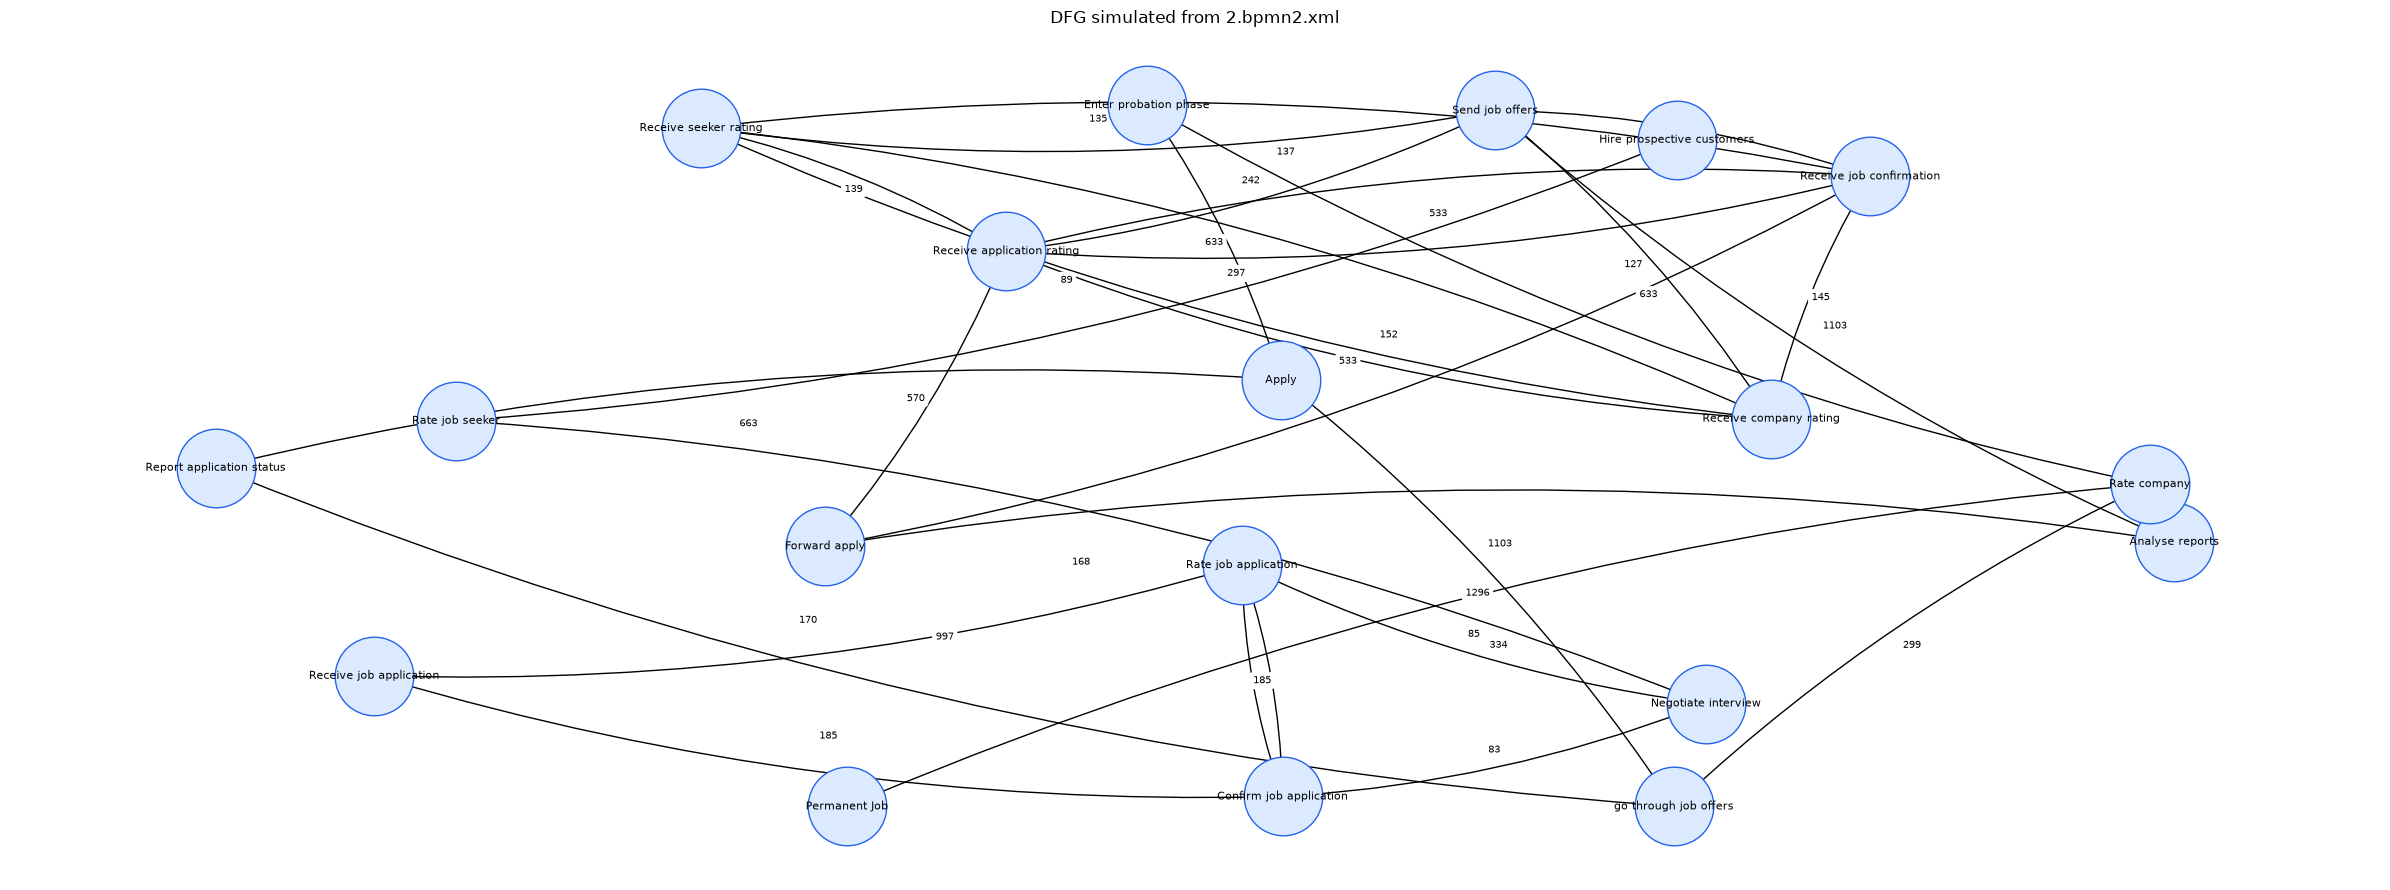

In [5]:
graph = nx.DiGraph()
for (source, target), frequency in dfg.items():
    graph.add_edge(source, target, frequency=frequency)

figure_width = max(12, min(24, 1.4 * len(graph.nodes)))
plt.figure(figsize=(figure_width, 9))
positions = nx.spring_layout(graph, seed=RANDOM_SEED, k=1.5)
nx.draw_networkx_nodes(graph, positions, node_color="#dbeafe", edgecolors="#2563eb", node_size=3200)
nx.draw_networkx_labels(graph, positions, font_size=8)
nx.draw_networkx_edges(graph, positions, arrows=True, arrowsize=18, connectionstyle="arc3,rad=0.08")
nx.draw_networkx_edge_labels(
    graph, positions,
    edge_labels=nx.get_edge_attributes(graph, "frequency"),
    font_size=7, rotate=False,
)
plt.title(f"DFG simulated from {BPMN_PATH.name}")
plt.axis("off")
plt.tight_layout()
plt.show()

## 6. Export the results

The PM4Py `.dfg` file preserves the graph plus start/end counts; the CSV is convenient for inspection.

In [ ]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
dfg_path = OUTPUT_DIR / f"{BPMN_PATH.stem}.dfg"
csv_path = OUTPUT_DIR / f"{BPMN_PATH.stem}_edges.csv"

pm4py.write_dfg(dfg, start_activities, end_activities, str(dfg_path))
edges.to_csv(csv_path, index=False)

print(f"PM4Py DFG: {dfg_path.resolve()}")
print(f"Edge table: {csv_path.resolve()}")

## Validation checklist and troubleshooting

- Confirm the completed trace count is greater than zero.
- Confirm `edges` contains the expected activities and paths.
- Re-run with a larger `NUMBER_OF_TRACES` and check whether the edge set stabilizes.
- If no trace completes, validate that the BPMN has reachable start/end events and sound gateway behavior, then increase `MAX_TRACE_LENGTH`.
- If import fails, ensure the file contains valid BPMN 2.0 XML; PM4Py accepts the repository's `.bpmn2.xml` extension.

### Mini-challenge

Change `BPMN_PATH` to another file under `bpmn/`, run all cells, and compare its activity and edge counts with the default model.